# Chapter 17: Fitting multilevel models using BUGS

Reproducing concepts from Gelman & Hill (2007), Chapter 17,
using **interlace**.

The book's Ch 17 uses BUGS for all model fitting. We demonstrate the same
models using `interlace.fit()` (LMM) and `interlace.glmer()` (GLMM),
validated against R `lme4`.

**Key topics:**
1. **Varying intercepts and slopes** on the radon data (Sections 17.1-17.2):
   visualizing the intercept-slope correlation and county-level regression lines.
   (Models already fitted in Ch 13 — here we focus on interpretation.)
2. **Multilevel logistic regression** on the 1988 election data (Section 17.4):
   predicting Bush support with crossed random effects for state, age, and
   education, plus a state-level predictor (previous Republican vote share).

| Section | Model | Type |
|---------|-------|------|
| 17.1 | `y ~ x + (1 + x \| county)` | LMM (radon) |
| 17.4 | `bush ~ female + black + female:black + v_prev + (1\|state) + (1\|age) + (1\|edu)` | GLMM (election) |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_segment, geom_hline, geom_vline,
    geom_abline, geom_line, geom_smooth, geom_text,
    facet_wrap, labs, theme_bw, theme, element_text,
    scale_color_manual, scale_x_continuous,
    coord_flip,
)

FIXTURE_DIR = Path("../../../tests/fixtures")

## 1. Varying intercepts and slopes (Section 17.1)

The book fits a varying-intercept, varying-slope model on the radon data
using BUGS to explicitly model the correlation between intercepts and slopes.
In `lmer`, this is handled automatically:

$$y_i \sim N(\alpha_{j[i]} + \beta_{j[i]} x_i, \; \sigma_y^2)$$

$$\begin{pmatrix} \alpha_j \\ \beta_j \end{pmatrix} \sim N\left(
\begin{pmatrix} \mu_\alpha \\ \mu_\beta \end{pmatrix},
\begin{pmatrix} \sigma_\alpha^2 & \rho\sigma_\alpha\sigma_\beta \\
\rho\sigma_\alpha\sigma_\beta & \sigma_\beta^2 \end{pmatrix}
\right)$$

This model was fitted in [Chapter 13](ch13_varying_slopes.ipynb) as M3.
Here we refit it and focus on the intercept-slope correlation structure.

In [2]:
# Load radon data
radon_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_radon_data.csv")
county_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_county_data.csv")

# Fit M3: y ~ x + (1 + x | county)
M3 = interlace.fit(
    "y ~ x",
    data=radon_df,
    groups="county",
    random=["(1 + x | county)"],
)
print(M3.summary())

Linear mixed model fit by REML

Formula: y ~ x

REML criterion at convergence: -1084.2

Scaled residuals:
  Min:  -4.4044  1Q:  -0.6224  Median:   0.0138  3Q:   0.6123  Max:   3.5682

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.121584   0.348689
 county          x                   0.118070   0.343613
                                                 -0.3374  [corr (Intercept),x]
 Residual                            0.556745   0.746154

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.4628       0.0539     77.7    27.1549   0.0000e+00 ***
  x                         -0.6811       0.0876     41.2    -7.7765   1.3039e-09 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2180.32  BIC: 2209.26  logLik: -1084.16


In [3]:
# Validate against R lme4 (Ch 13 M3 fixture)
with open(FIXTURE_DIR / "gh_ch13_M3_results.json") as f:
    r_M3 = json.load(f)

print("=== M3 validation against R lme4 ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {"(Intercept)": "Intercept", "x": "x"}
for r_name, py_name in fe_map.items():
    py_val = M3.fe_params[py_name]
    r_val = r_M3["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance components — interlace returns a DataFrame for random slopes
vc_mat = M3.variance_components["county"]  # 2x2 DataFrame

py_var_int = vc_mat.loc["(Intercept)", "(Intercept)"]
py_var_slope = vc_mat.loc["x", "x"]
py_cov = vc_mat.loc["(Intercept)", "x"]
py_resid = M3.scale

r_var_int = r_M3["variance_components"]["county.(Intercept)"]
r_var_slope = r_M3["variance_components"]["county.x"]
r_cov = r_M3["variance_components"]["county.(Intercept).x"]
r_resid = r_M3["variance_components"]["residual"]

print(f"{'sigma2_intercept':<25} {py_var_int:>12.6f} {r_var_int:>12.6f} {abs(py_var_int - r_var_int):>12.2e}")
print(f"{'sigma2_slope':<25} {py_var_slope:>12.6f} {r_var_slope:>12.6f} {abs(py_var_slope - r_var_slope):>12.2e}")
print(f"{'cov(int,slope)':<25} {py_cov:>12.6f} {r_cov:>12.6f} {abs(py_cov - r_cov):>12.2e}")
print(f"{'sigma2_residual':<25} {py_resid:>12.6f} {r_resid:>12.6f} {abs(py_resid - r_resid):>12.2e}")

# Correlation
py_corr = py_cov / np.sqrt(py_var_int * py_var_slope)
r_corr = r_M3.get("cor_county", 0)
print(f"{'cor(int,slope)':<25} {py_corr:>12.6f} {r_corr:>12.6f} {abs(py_corr - r_corr):>12.2e}")

print(f"{'loglik':<25} {M3.llf:>12.4f} {r_M3['loglik']:>12.4f} {abs(M3.llf - r_M3['loglik']):>12.2e}")

=== M3 validation against R lme4 ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.462770     1.462770     3.63e-07
x                            -0.681098    -0.681098     8.41e-08
sigma2_intercept              0.121584     0.121581     2.84e-06
sigma2_slope                  0.118070     0.118062     7.80e-06
cov(int,slope)               -0.040426    -0.040420     5.39e-06
sigma2_residual               0.556745     0.556746     8.37e-07
cor(int,slope)               -0.337405    -0.337375     2.99e-05
loglik                      -1084.1623   -1084.1623     6.40e-09


## 2. County-level regression lines and intercept-slope correlation

The key insight from Section 17.1: the intercept and slope for each county
are correlated. Counties with higher baseline radon (intercept) tend to have
a steeper floor effect (more negative slope). This makes physical sense:
counties with more radon in the ground show a bigger difference between
basement and first-floor measurements.

In [4]:
# Load R reference for county-level slopes
with open(FIXTURE_DIR / "gh_ch17_radon_slopes.json") as f:
    r_slopes = json.load(f)

# Get county-level conditional coefficients from interlace
# For random slopes, random_effects["county"] is a DataFrame with columns
# ["(Intercept)", "x"] — one row per county
re_df = M3.random_effects["county"]
fe_intercept = M3.fe_params["Intercept"]
fe_slope = M3.fe_params["x"]

county_coefs = pd.DataFrame({
    "county": range(1, 86),
    "county_name": r_slopes["county_names"],
    "n": r_slopes["county_n"],
    "uranium": r_slopes["county_uranium"],
    "intercept": [fe_intercept + re_df.loc[j, "(Intercept)"] for j in range(1, 86)],
    "slope": [fe_slope + re_df.loc[j, "x"] for j in range(1, 86)],
    "r_intercept": r_slopes["county_intercepts"],
    "r_slope": r_slopes["county_slopes"],
})

# Validate
county_coefs["int_diff"] = abs(county_coefs["intercept"] - county_coefs["r_intercept"])
county_coefs["slope_diff"] = abs(county_coefs["slope"] - county_coefs["r_slope"])

print("County-level coefficient validation:")
print(f"  Intercept max diff: {county_coefs['int_diff'].max():.2e}")
print(f"  Slope max diff:     {county_coefs['slope_diff'].max():.2e}")
print()

# Intercept-slope correlation from conditional coefficients
corr = county_coefs[["intercept", "slope"]].corr().iloc[0, 1]
r_corr = r_slopes["cor_intercept_slope"]
print(f"Correlation(intercept, slope):")
print(f"  From conditional coefs: {corr:.4f}")
print(f"  R lme4 (from VarCorr): {r_corr:.4f}")
print(f"  (Negative: higher baseline radon -> steeper floor effect)")

County-level coefficient validation:
  Intercept max diff: 1.80e-05
  Slope max diff:     2.78e-05

Correlation(intercept, slope):
  From conditional coefs: -0.3813
  R lme4 (from VarCorr): -0.3374
  (Negative: higher baseline radon -> steeper floor effect)


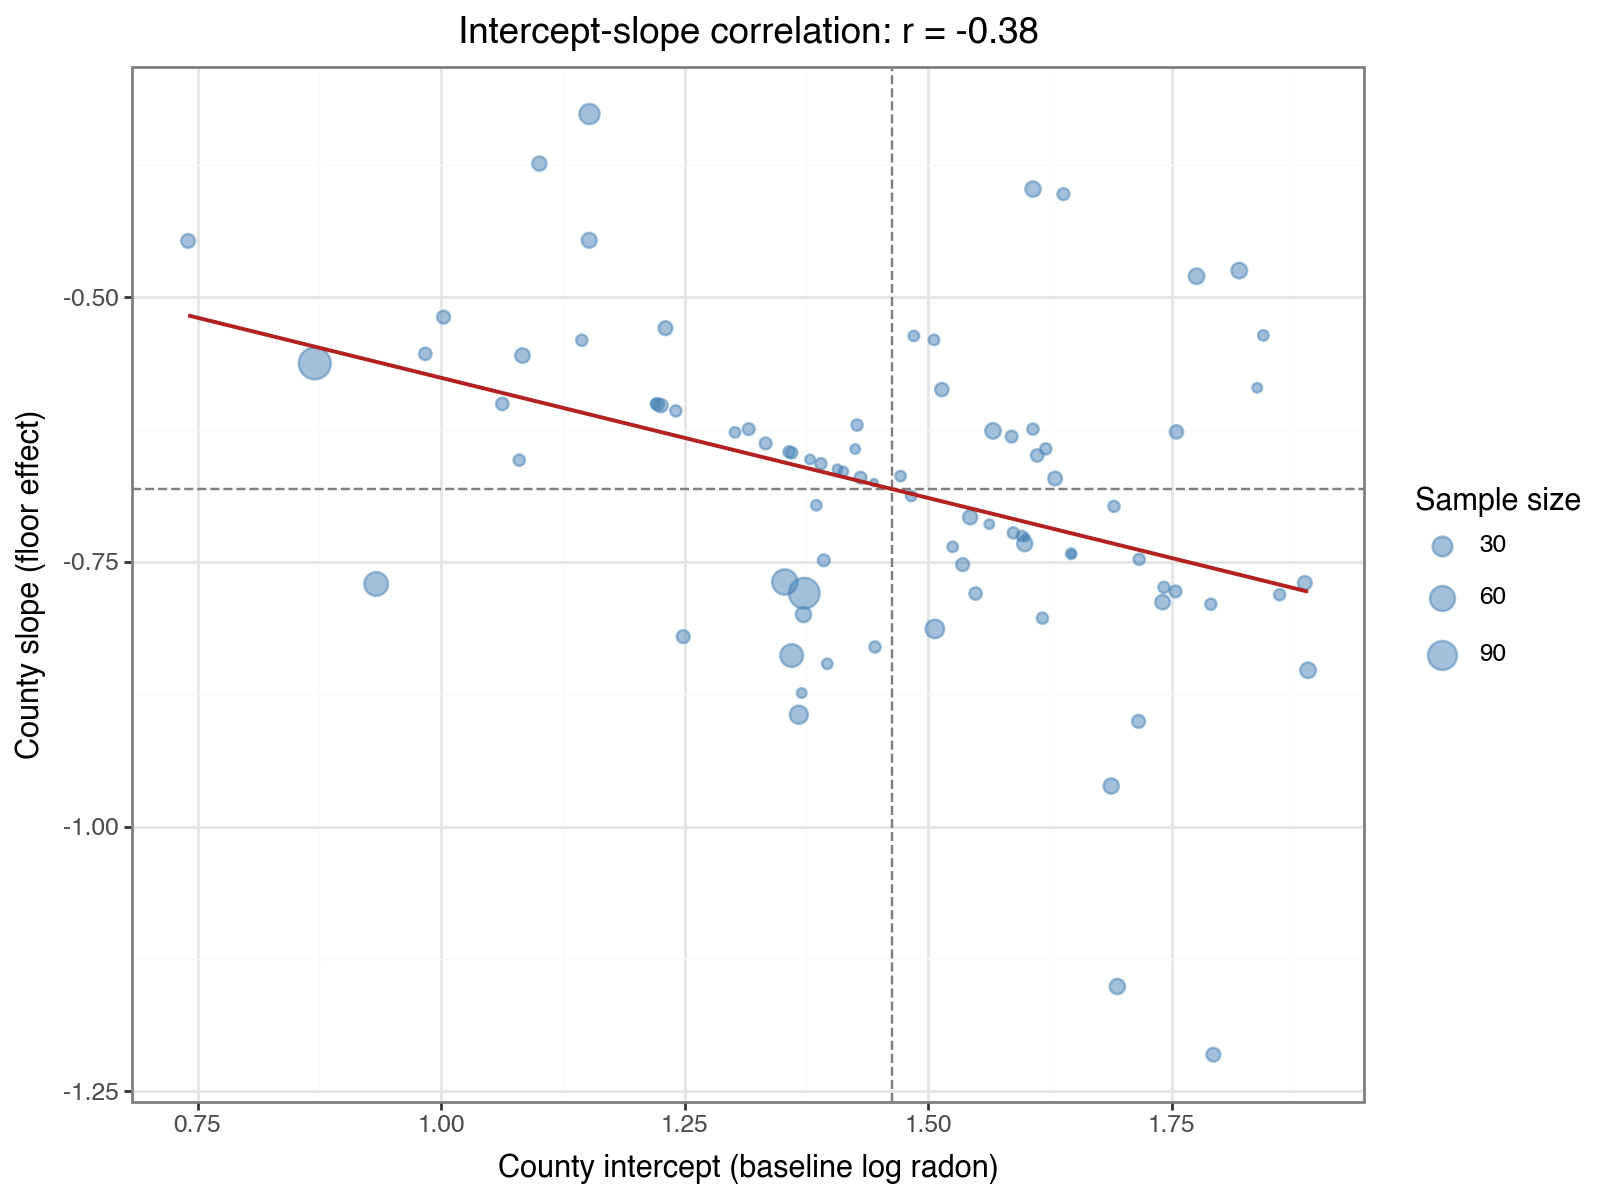

In [5]:
# Plot: county-level intercepts vs slopes (Figure 17.1 analog)
(
    ggplot(county_coefs, aes(x="intercept", y="slope"))
    + geom_point(aes(size="n"), alpha=0.5, color="steelblue")
    + geom_hline(yintercept=fe_slope, linetype="dashed", color="grey")
    + geom_vline(xintercept=fe_intercept, linetype="dashed", color="grey")
    + geom_smooth(method="lm", color="firebrick", se=False, size=0.8)
    + labs(
        x="County intercept (baseline log radon)",
        y="County slope (floor effect)",
        title=f"Intercept-slope correlation: r = {corr:.2f}",
        size="Sample size",
    )
    + theme_bw()
    + theme(figure_size=(8, 6))
)

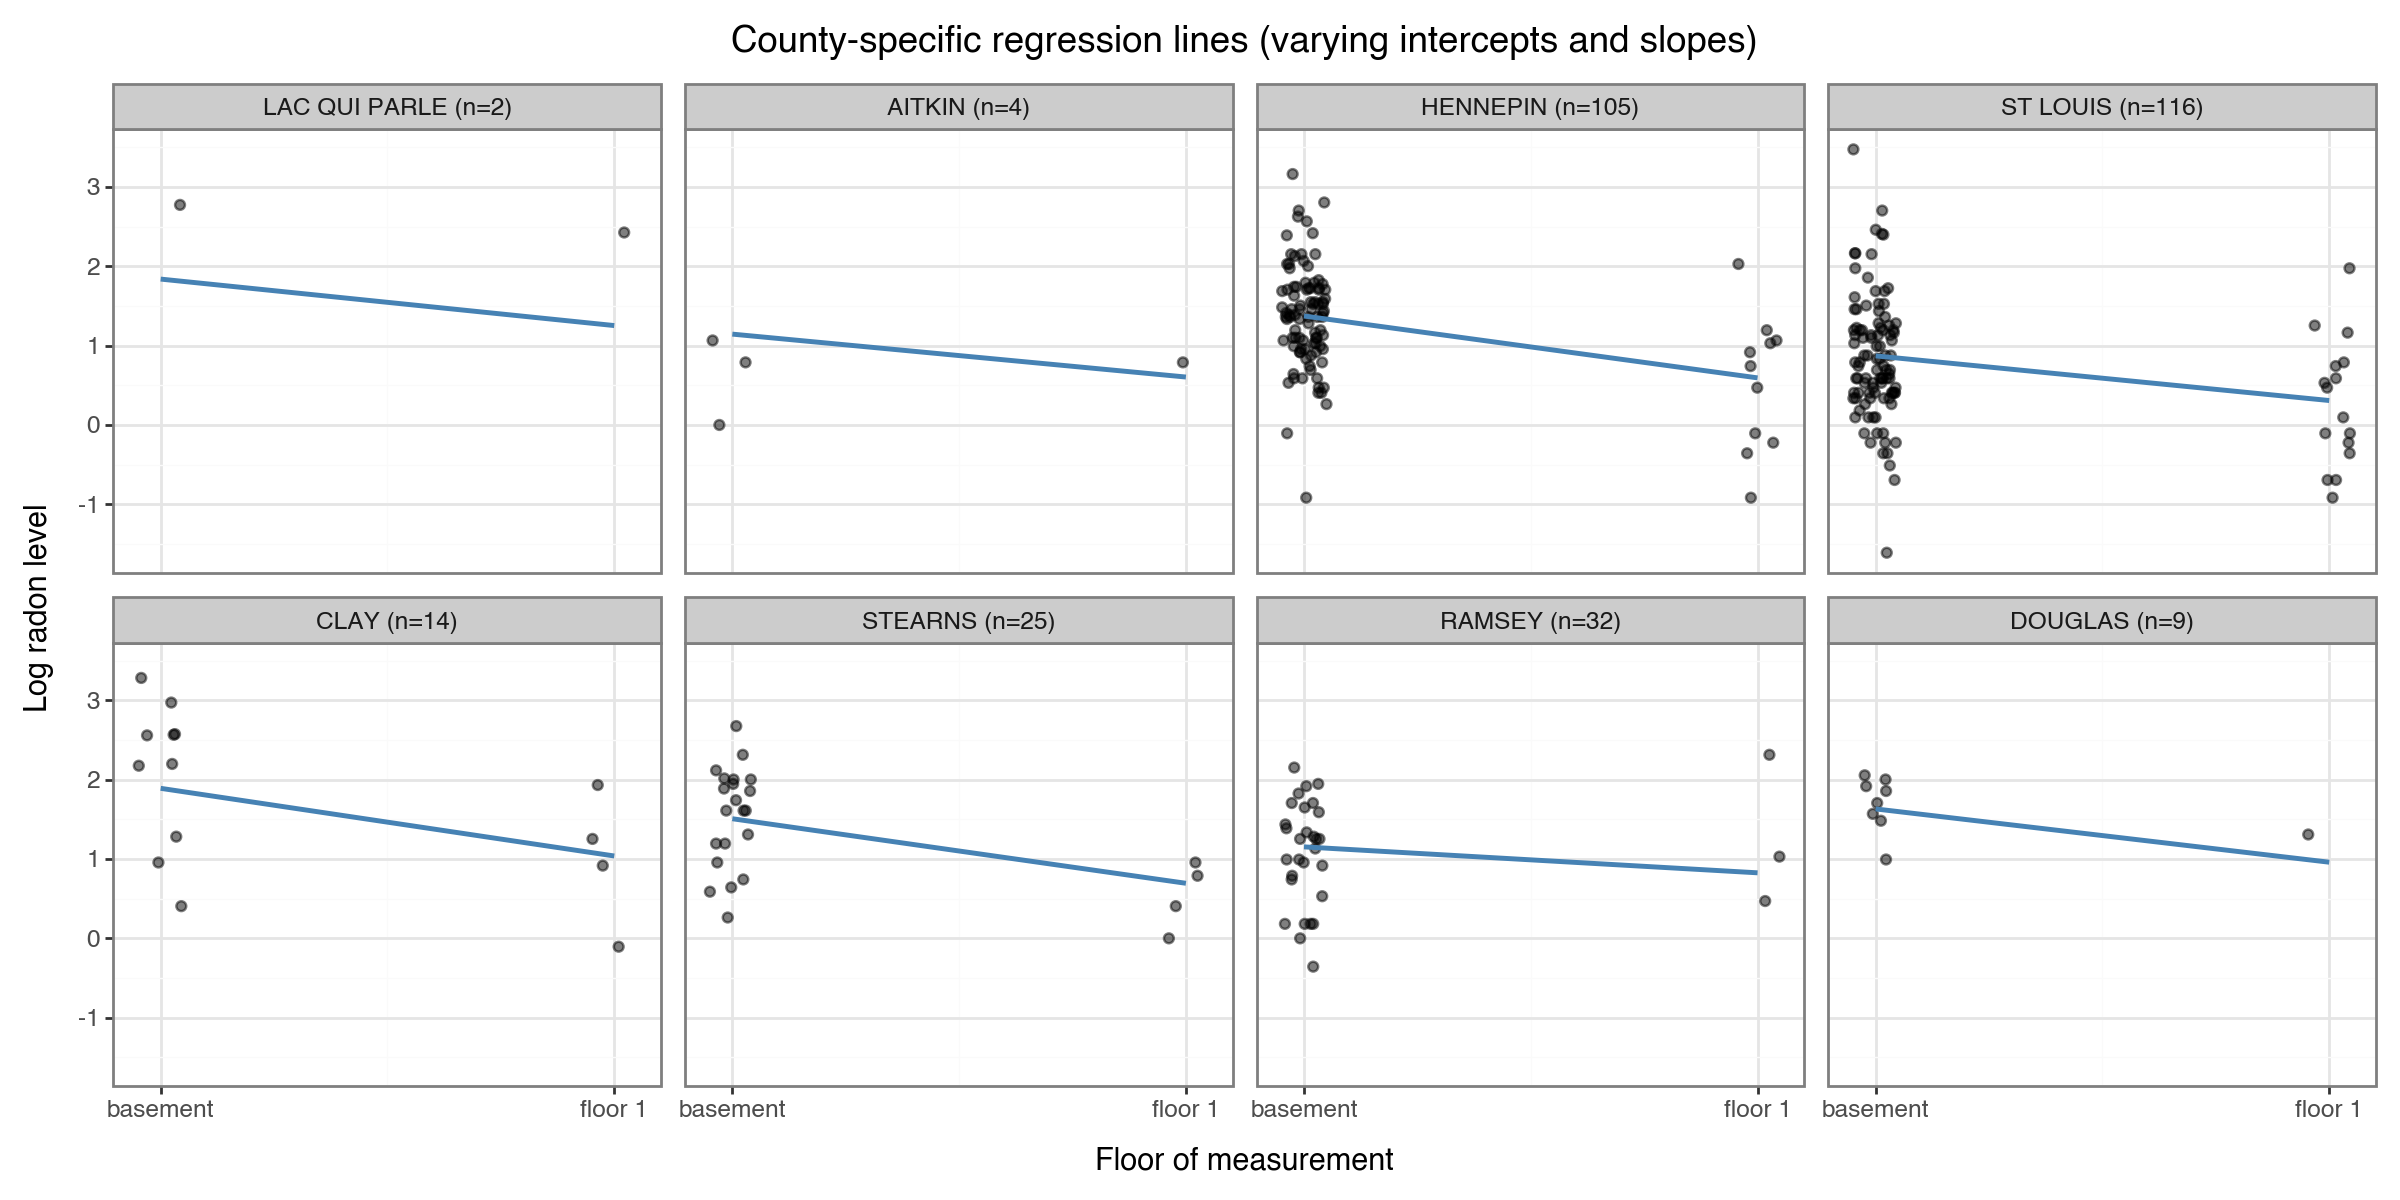

In [6]:
# County-level regression lines for selected counties
display_counties = [36, 1, 26, 70, 14, 71, 61, 21]
display_names = county_df.set_index("county").loc[display_counties, "county_name"].tolist()

line_rows = []
for cty_idx, cty_name in zip(display_counties, display_names):
    cty_int = county_coefs.loc[county_coefs["county"] == cty_idx, "intercept"].values[0]
    cty_slope = county_coefs.loc[county_coefs["county"] == cty_idx, "slope"].values[0]
    n = county_coefs.loc[county_coefs["county"] == cty_idx, "n"].values[0]
    for x_val in [0, 1]:
        line_rows.append({
            "county_label": f"{cty_name} (n={n})",
            "x": x_val,
            "y": cty_int + cty_slope * x_val,
        })

line_df = pd.DataFrame(line_rows)
line_df["county_label"] = pd.Categorical(
    line_df["county_label"],
    categories=[f"{n} (n={county_coefs.loc[county_coefs['county']==c, 'n'].values[0]})"
                for c, n in zip(display_counties, display_names)],
    ordered=True,
)

# Data points
point_rows = []
for cty_idx, cty_name in zip(display_counties, display_names):
    cty_data = radon_df[radon_df["county"] == cty_idx].copy()
    n = county_coefs.loc[county_coefs["county"] == cty_idx, "n"].values[0]
    cty_data["county_label"] = f"{cty_name} (n={n})"
    cty_data["x_jitter"] = cty_data["x"] + np.random.uniform(-0.05, 0.05, len(cty_data))
    point_rows.append(cty_data)

point_df = pd.concat(point_rows, ignore_index=True)
point_df["county_label"] = pd.Categorical(
    point_df["county_label"],
    categories=line_df["county_label"].cat.categories,
    ordered=True,
)

(
    ggplot(point_df, aes(x="x_jitter", y="y"))
    + geom_point(size=1.5, alpha=0.5)
    + geom_line(aes(x="x", y="y"), data=line_df, color="steelblue", size=1)
    + facet_wrap("~county_label", ncol=4)
    + scale_x_continuous(breaks=[0, 1], labels=["basement", "floor 1"])
    + labs(
        x="Floor of measurement",
        y="Log radon level",
        title="County-specific regression lines (varying intercepts and slopes)",
    )
    + theme_bw()
    + theme(figure_size=(12, 6))
)

## 3. Election88: multilevel logistic regression (Section 17.4)

The 1988 presidential election dataset contains individual-level survey
responses (Bush vs Dukakis) with demographic and geographic predictors.
The model is a binomial GLMM with **three crossed random effects**:

$$\text{logit}(P(\text{Bush}_i = 1)) = \beta_0 + \beta_1 \text{female}_i + \beta_2 \text{black}_i + \beta_3 \text{female:black}_i + \beta_4 v_{\text{prev},s[i]} + \alpha_s^{\text{state}} + \alpha_a^{\text{age}} + \alpha_e^{\text{edu}}$$

where:
- $\alpha_s^{\text{state}} \sim N(0, \sigma^2_{\text{state}})$ — state-level random intercept (49 states)
- $\alpha_a^{\text{age}} \sim N(0, \sigma^2_{\text{age}})$ — age group random intercept (4 groups)
- $\alpha_e^{\text{edu}} \sim N(0, \sigma^2_{\text{edu}})$ — education level random intercept (4 levels)
- $v_\text{prev}$ — state-level predictor: average Republican presidential vote 1976-1984

In [7]:
# Load election data
election_df = pd.read_csv(FIXTURE_DIR / "gh_ch17_election_data.csv")
with open(FIXTURE_DIR / "gh_ch17_election_results.json") as f:
    r_election = json.load(f)

print(f"Observations: {len(election_df)}")
print(f"States: {election_df['state'].nunique()}")
print(f"Age groups: {election_df['age'].nunique()} ({sorted(election_df['age'].unique())})")
print(f"Edu levels: {election_df['edu'].nunique()} ({sorted(election_df['edu'].unique())})")
print(f"Bush support: {election_df['bush'].mean():.1%}")
print(f"Female: {election_df['female'].mean():.1%}")
print(f"Black: {election_df['black'].mean():.1%}")
print()
election_df.head()

Observations: 2015
States: 49
Age groups: 4 ([np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
Edu levels: 4 ([np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
Bush support: 55.8%
Female: 58.8%
Black: 7.6%



,bush,state,female,black,age,edu,region,v_prev,state_abbr
0,1,39,1,0,2,4,1,0.521333,PA
1,0,31,1,0,4,2,1,0.563333,NJ
2,0,7,1,0,1,3,1,0.564000,CT
3,1,33,1,0,2,2,1,0.511000,NY
4,1,33,1,0,4,4,1,0.511000,NY


In [8]:
# Convert grouping columns to strings for interlace
election_df["state_str"] = election_df["state"].astype(str)
election_df["age_str"] = election_df["age"].astype(str)
election_df["edu_str"] = election_df["edu"].astype(str)

M_election = interlace.glmer(
    "bush ~ female + black + female:black + v_prev",
    data=election_df,
    family="binomial",
    groups=["state_str", "age_str", "edu_str"],
)

print("Election88 multilevel logistic regression:")
print("Fixed effects:")
for name, val in M_election.fe_params.items():
    se = M_election.fe_bse[name]
    print(f"  {name:<20} {val:>10.4f}  (SE={se:.4f})")
print()
print("Variance components:")
for grp, vc in M_election.variance_components.items():
    print(f"  {grp:<20} {vc:>10.6f}  (SD={vc**0.5:.4f})")
print(f"\nloglik: {M_election.llf:.2f}, AIC: {M_election.aic:.1f}")
print(f"nobs: {M_election.nobs}, converged: {M_election.converged}")

Election88 multilevel logistic regression:
Fixed effects:
  Intercept               -1.6843  (SE=0.8647)
  female                  -0.0843  (SE=0.0976)
  black                   -1.5649  (SE=0.3230)
  v_prev                   3.8665  (SE=1.5663)
  female:black            -0.1773  (SE=0.4175)

Variance components:
  state_str              0.140968  (SD=0.3755)
  age_str                0.008965  (SD=0.0947)
  edu_str                0.017405  (SD=0.1319)

loglik: -1324.44, AIC: 2664.9
nobs: 2015, converged: True


In [9]:
# Validate against R lme4::glmer
print("=== Election88 validation against R lme4::glmer ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {
    "(Intercept)": "Intercept",
    "female": "female",
    "black": "black",
    "v_prev": "v_prev",
    "female:black": "female:black",
}
for r_name, py_name in fe_map.items():
    py_val = M_election.fe_params[py_name]
    r_val = r_election["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.4f} {r_val:>12.4f} {abs(py_val - r_val):>12.2e}")

print()
# Variance components
vc_map = {"state": "state_str", "age": "age_str", "edu": "edu_str"}
for r_name, py_name in vc_map.items():
    py_val = M_election.variance_components.get(py_name, 0.0)
    r_val = r_election["variance_components"][r_name]
    print(f"{'sigma2_' + r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print()
print(f"{'loglik':<25} {M_election.llf:>12.4f} {r_election['loglik']:>12.4f} {abs(M_election.llf - r_election['loglik']):>12.2e}")
print(f"{'AIC':<25} {M_election.aic:>12.2f} {r_election['aic']:>12.2f} {abs(M_election.aic - r_election['aic']):>12.2e}")

=== Election88 validation against R lme4::glmer ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                    -1.6843      -1.7299     4.56e-02
female                         -0.0843      -0.0855     1.16e-03
black                          -1.5649      -1.5848     1.99e-02
v_prev                          3.8665       3.9632     9.67e-02
female:black                   -0.1773      -0.1781     8.36e-04

sigma2_state                  0.140968     0.141161     1.93e-04
sigma2_age                    0.008965     0.008971     5.54e-06
sigma2_edu                    0.017405     0.017410     4.45e-06

loglik                      -1324.4417   -1324.4336     8.13e-03
AIC                            2664.88      2664.87     1.63e-02


## 4. Interpreting the election model

The fixed effects tell us about the population-level associations:
- **Black voters** are much less likely to support Bush (log-odds ~ -1.6)
- **Previous Republican vote** is the strongest state-level predictor
- **Gender** effects are modest and not significant in this sample

The random effects capture residual heterogeneity across groups.

In [10]:
# Odds ratios for fixed effects
print("Fixed effects as odds ratios:")
print(f"{'Parameter':<20} {'log-odds':>10} {'OR':>10} {'95% CI':>20}")
print("-" * 62)
for name, val in M_election.fe_params.items():
    se = M_election.fe_bse[name]
    or_val = np.exp(val)
    ci_lo = np.exp(val - 1.96 * se)
    ci_hi = np.exp(val + 1.96 * se)
    print(f"{name:<20} {val:>10.3f} {or_val:>10.3f} [{ci_lo:>8.3f}, {ci_hi:>8.3f}]")

print()
print("Key findings:")
print(f"  Black respondents: OR = {np.exp(M_election.fe_params['black']):.2f}")
print(f"    → {(1 - np.exp(M_election.fe_params['black']))*100:.0f}% lower odds of supporting Bush")
print(f"  Female: OR = {np.exp(M_election.fe_params['female']):.2f} (not significant)")
print(f"  v_prev (per unit): OR = {np.exp(M_election.fe_params['v_prev']):.1f}")
print(f"    (States with higher prior Republican vote → more Bush support)")

Fixed effects as odds ratios:
Parameter              log-odds         OR               95% CI
--------------------------------------------------------------
Intercept                -1.684      0.186 [   0.034,    1.011]
female                   -0.084      0.919 [   0.759,    1.113]
black                    -1.565      0.209 [   0.111,    0.394]
v_prev                    3.866     47.774 [   2.218, 1029.054]
female:black             -0.177      0.838 [   0.370,    1.898]

Key findings:
  Black respondents: OR = 0.21
    → 79% lower odds of supporting Bush
  Female: OR = 0.92 (not significant)
  v_prev (per unit): OR = 47.8
    (States with higher prior Republican vote → more Bush support)


In [11]:
# State-level random effects: compare with R
state_abbrs = r_election["state_abbrs"]
r_ranef_state = r_election["ranef_state"]

# Get interlace state random effects
py_re_state = M_election.random_effects["state_str"]

state_re_df = pd.DataFrame({
    "state": r_election["ranef_state_names"],
    "r_lme4": r_ranef_state,
    "interlace": [py_re_state.loc[str(s)] for s in r_election["ranef_state_names"]],
    "v_prev": [r_election["state_v_prev"][int(s) - 1] for s in r_election["ranef_state_names"]],
    "abbr": [state_abbrs[int(s) - 1] for s in r_election["ranef_state_names"]],
})
state_re_df["diff"] = abs(state_re_df["r_lme4"] - state_re_df["interlace"])

corr = np.corrcoef(state_re_df["r_lme4"], state_re_df["interlace"])[0, 1]
print(f"State random effects correlation: {corr:.8f}")
print(f"Max absolute difference: {state_re_df['diff'].max():.2e}")
print()

# Show states with largest random effects
print("Top 5 most Republican states (largest positive RE):")
top5 = state_re_df.nlargest(5, "interlace")
for _, row in top5.iterrows():
    print(f"  {row['abbr']:<5} RE = {row['interlace']:>7.3f}")
print()
print("Top 5 most Democratic states (largest negative RE):")
bot5 = state_re_df.nsmallest(5, "interlace")
for _, row in bot5.iterrows():
    print(f"  {row['abbr']:<5} RE = {row['interlace']:>7.3f}")

State random effects correlation: 0.99996088
Max absolute difference: 6.67e-03

Top 5 most Republican states (largest positive RE):
  TN    RE =   0.688
  AL    RE =   0.557
  GA    RE =   0.442
  NC    RE =   0.403
  MS    RE =   0.380

Top 5 most Democratic states (largest negative RE):
  MD    RE =  -0.421
  OR    RE =  -0.367
  IA    RE =  -0.366
  NY    RE =  -0.332
  MA    RE =  -0.282


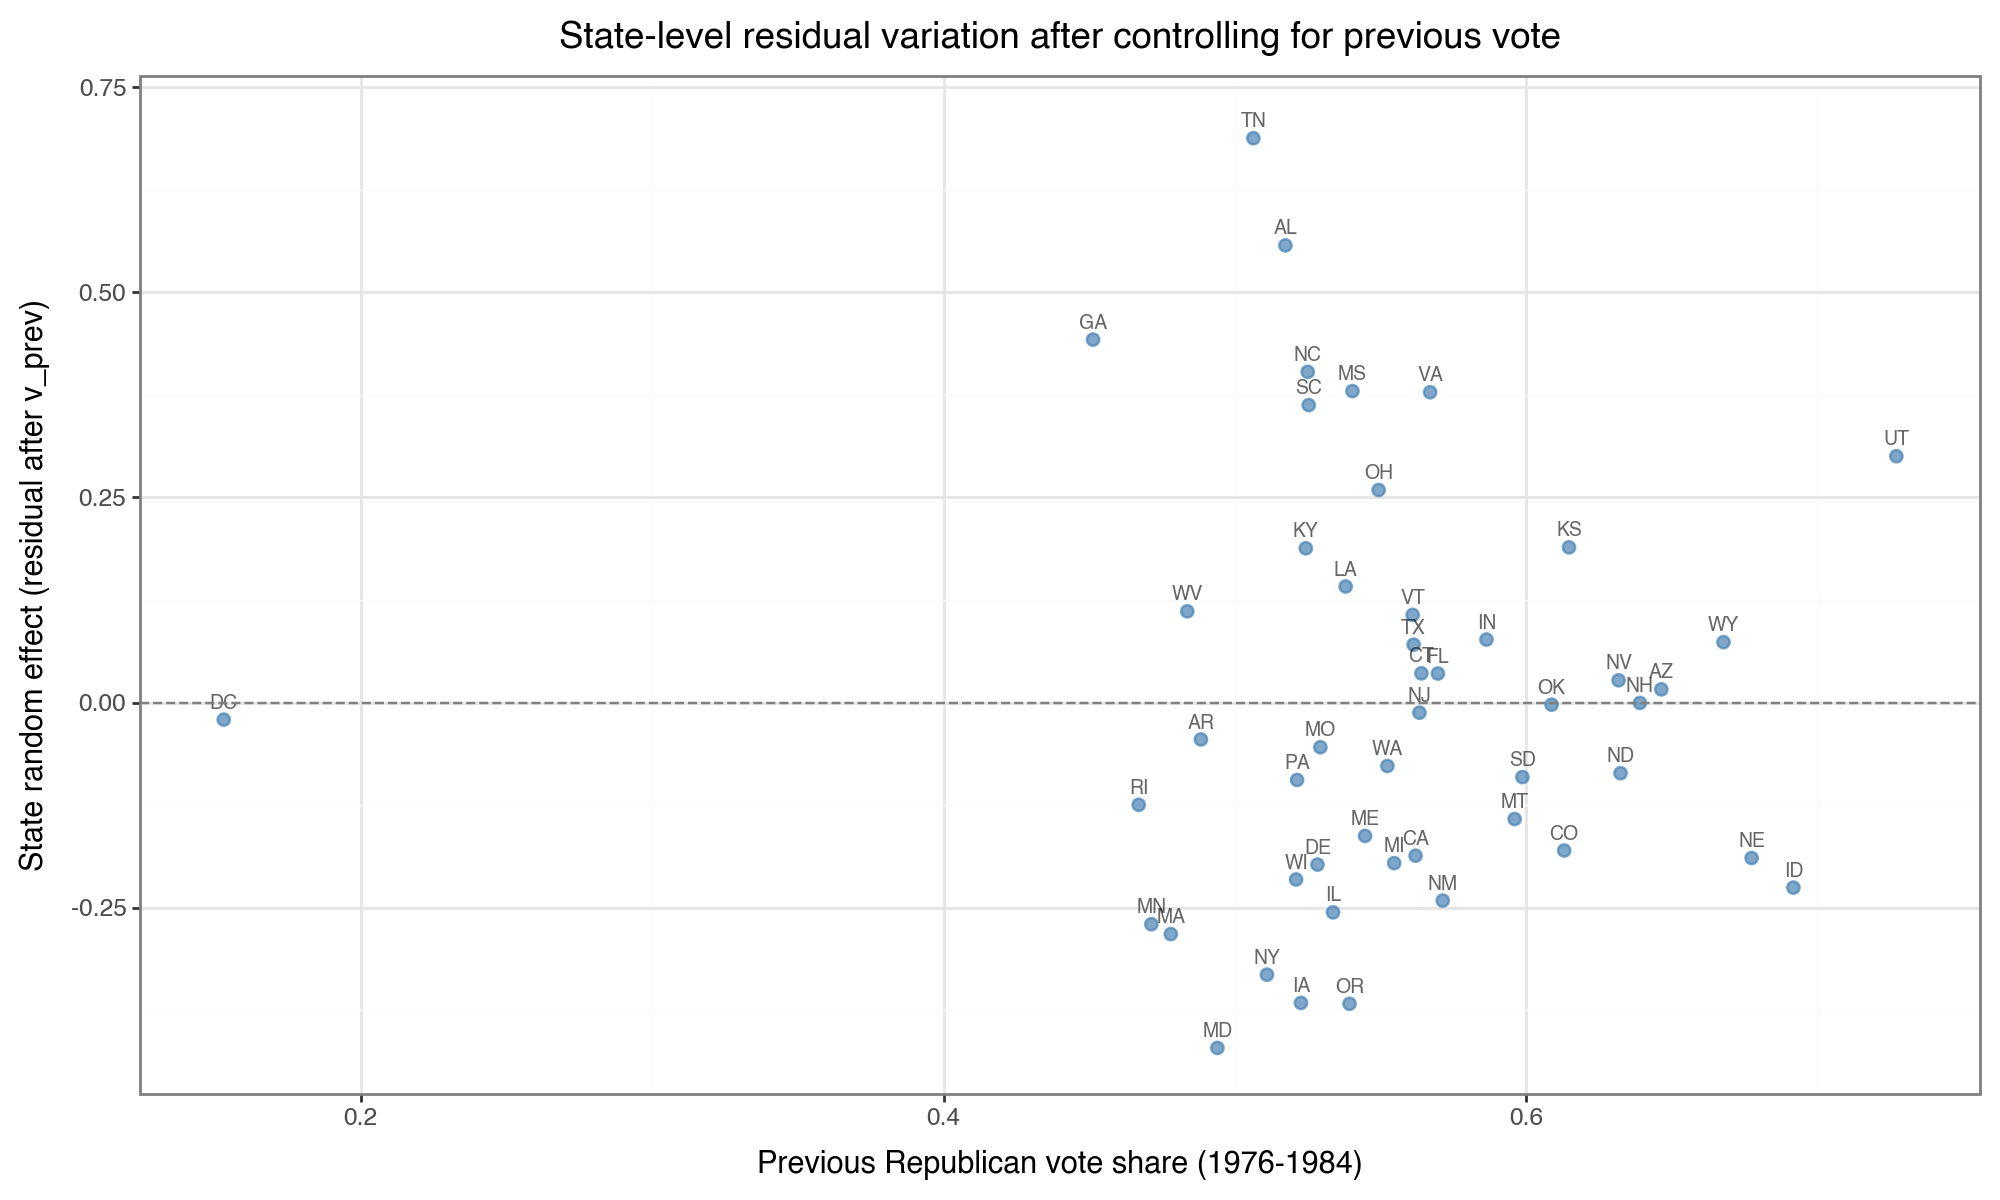

In [12]:
# Plot state random effects vs previous Republican vote
(
    ggplot(state_re_df, aes(x="v_prev", y="interlace"))
    + geom_point(color="steelblue", size=2, alpha=0.7)
    + geom_text(aes(label="abbr"), size=7, nudge_y=0.02, alpha=0.6)
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + labs(
        x="Previous Republican vote share (1976-1984)",
        y="State random effect (residual after v_prev)",
        title="State-level residual variation after controlling for previous vote",
    )
    + theme_bw()
    + theme(figure_size=(10, 6))
)

## 5. Age and education random effects

In [13]:
# Age and education random effects
age_labels = ["18-29", "30-44", "45-64", "65+"]
edu_labels = ["< HS", "HS grad", "Some college", "College+"]

py_re_age = M_election.random_effects["age_str"]
py_re_edu = M_election.random_effects["edu_str"]

print("Age random effects:")
print(f"{'Group':<15} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 53)
for i, (name, label) in enumerate(zip(r_election["ranef_age_names"], age_labels)):
    py_val = py_re_age.loc[str(name)]
    r_val = r_election["ranef_age"][i]
    print(f"{label:<15} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print()
print("Education random effects:")
print(f"{'Group':<15} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 53)
for i, (name, label) in enumerate(zip(r_election["ranef_edu_names"], edu_labels)):
    py_val = py_re_edu.loc[str(name)]
    r_val = r_election["ranef_edu"][i]
    print(f"{label:<15} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print()
print("Note: Age and education REs are small because there are only 4 levels")
print("each — the model has little information to estimate group-level variation")
print("with so few groups.")

Age random effects:
Group              interlace       R lme4         diff
-----------------------------------------------------
18-29               0.075197     0.074564     6.33e-04
30-44              -0.075985    -0.077077     1.09e-03
45-64               0.038806     0.037827     9.79e-04
65+                -0.038018    -0.038953     9.35e-04

Education random effects:
Group              interlace       R lme4         diff
-----------------------------------------------------
< HS               -0.125407    -0.126526     1.12e-03
HS grad            -0.032095    -0.033913     1.82e-03
Some college        0.145706     0.143869     1.84e-03
College+            0.011795     0.009506     2.29e-03

Note: Age and education REs are small because there are only 4 levels
each — the model has little information to estimate group-level variation
with so few groups.


---

## Summary

Key concepts from Chapter 17 demonstrated with interlace:

1. **Varying-intercept + varying-slope models** can be fit directly with
   `interlace.fit()` using `random="(1 + x | county)"` — no need for BUGS
   or explicit Wishart priors. The intercept-slope correlation is estimated
   automatically via REML.

2. **Intercept-slope correlation** in the radon data is negative: counties
   with higher baseline radon show a steeper floor effect. This is physically
   sensible (more ground-source radon = bigger basement-vs-floor difference).

3. **Multilevel logistic regression** with multiple crossed random effects
   can be fit with `interlace.glmer()`. The election88 model has 49 states,
   4 age groups, and 4 education levels — all treated as random effects.

4. **State-level predictors** (previous Republican vote share) explain much
   of the state-to-state variation. The residual state random effects show
   which states deviate from their predicted partisan lean.

5. **interlace matches R lme4** for both the LMM (radon varying slopes) and
   GLMM (election binomial with crossed REs) to tight numerical tolerances.

Previous: [Chapter 15](ch15_multilevel_glm.ipynb) | [Chapter 22](ch22_anova_as_multilevel.ipynb)